In [1]:
from pathlib import Path
import yaml, json

ROOT = Path.cwd()
DATA = ROOT / "data_yolo_dish"
assert (DATA/"train/images").exists(), "Missing train/images in data_yolo_dish"
assert (DATA/"val/images").exists() or (DATA/"valid/images").exists(), "Missing val/valid in data_yolo_dish"

val_key = "val" if (DATA/"val/images").exists() else "valid"

NAMES = ["dish"]

yaml_dict = {
    "path": DATA.resolve().as_posix(),
    "train": "train/images",
    "val":   f"{val_key}/images",
    "names": NAMES
}
( DATA/"data.yaml" ).write_text(yaml.safe_dump(yaml_dict, sort_keys=False), encoding="utf-8")
print("Wrote", (DATA/"data.yaml").resolve())
print((DATA/"data.yaml").read_text())


Wrote C:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\data_yolo_dish\data.yaml
path: C:/Users/Jun Wei/Desktop/SIT/SIT Y2T1/Computer Vision and Deep Learning/Proj/food_classifier/data_yolo_dish
train: train/images
val: valid/images
names:
- dish



In [2]:
from ultralytics import YOLO
import torch
from pathlib import Path

DATA_YAML = Path("data_yolo_dish/data.yaml")
assert DATA_YAML.exists()

model = YOLO("yolov8n.pt")

model = YOLO("yolov8n.pt")
results = model.train(
    data="data_yolo_dish/data.yaml",
    imgsz=768,
    epochs=80,
    batch=16,
    patience=20,
    name="train_dishdet_multi",
    lr0=0.01, lrf=0.1,
    mosaic=1.0, mixup=0.2, copy_paste=0.3,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    translate=0.1, scale=0.5, fliplr=0.5,
    erasing=0.2, cos_lr=True, amp=True, cache="ram",
)
best_weights = model.trainer.best
print("Best weights:", best_weights)


New https://pypi.org/project/ultralytics/8.3.232 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.5  Python-3.11.9 torch-2.3.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=data_yolo_dish/data.yaml, epochs=80, time=None, patience=20, batch=16, imgsz=768, save=True, save_period=-1, cache=ram, device=None, workers=8, project=None, name=train_dishdet_multi3, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed

train: Scanning C:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\data_yolo_dish\train\labels.cache... 903 images, 0 backgrounds, 0 corrupt: 100%|██████████| 903/903 [00:00<?, ?it/s]

WARNING  Box and segment counts should be equal, but got len(segments) = 83, len(boxes) = 5212. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.


WARNING  cache='ram' may produce non-deterministic training results. Consider cache='disk' as a deterministic alternative if your disk space allows.


train: Caching images (1.0GB RAM): 100%|██████████| 903/903 [00:06<00:00, 137.25it/s]
val: Scanning C:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\data_yolo_dish\valid\labels.cache... 181 images, 0 backgrounds, 0 corrupt: 100%|██████████| 181/181 [00:00<?, ?it/s]

...

      80/80      3.48G     0.4032     0.2995     0.8987         58        768: 100%|██████████| 57/57 [00:18<00:00,  3.04it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:04<00:00,  1.48it/s]

                   all        181       1004      0.871      0.891      0.916      0.822



80 epochs completed in 0.650 hours.
Optimizer stripped from c:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\runs\detect\train_dishdet_multi3\weights\last.pt, 5.7MB
Optimizer stripped from c:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\runs\detect\train_dishdet_multi3\weights\best.pt, 5.7MB

Validating c:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\runs\detect\train_dishdet_multi3\weights\best.pt...
Ultralytics 8.3.5  Python-3.11.9 torch-2.3.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 186 layers, 2,684,563 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:05<00:00,  1.08it/s]


                   all        181       1004      0.851      0.905      0.917      0.827
Speed: 1.6ms preprocess, 5.5ms inference, 0.0ms loss, 3.5ms postprocess per image
Results saved to c:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\runs\detect\train_dishdet_multi3
Best weights: c:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\runs\detect\train_dishdet_multi3\weights\best.pt


In [3]:
from ultralytics import YOLO
from pathlib import Path

best_weights = Path("runs/detect/train_dishdet_multi3/weights/best.pt")
yolo_best = YOLO(str(best_weights))

metrics = yolo_best.val(data="data_yolo_dish/data.yaml", imgsz=768)
print("mAP50:", metrics.results_dict.get("metrics/mAP50(B)"))
print("mAP50-95:", metrics.results_dict.get("metrics/mAP50-95(B)"))

Ultralytics 8.3.5  Python-3.11.9 torch-2.3.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 186 layers, 2,684,563 parameters, 0 gradients


val: Scanning C:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\data_yolo_dish\valid\labels.cache... 181 images, 0 backgrounds, 0 corrupt: 100%|██████████| 181/181 [00:00<?, ?it/s]

WARNING  Box and segment counts should be equal, but got len(segments) = 28, len(boxes) = 1004. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 12/12 [00:04<00:00,  2.86it/s]


                   all        181       1004      0.852      0.905      0.917      0.828
Speed: 0.6ms preprocess, 6.8ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to c:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\runs\detect\val4
mAP50: 0.9171988930709991
mAP50-95: 0.827593172022414


In [3]:
from pathlib import Path
import os, json, numpy as np
import cv2
from PIL import Image, ImageDraw, ImageFont

import tensorflow as tf
from tensorflow import keras
from ultralytics import YOLO

BASE_DIR = Path.cwd()
CLASSMAP_JSON = BASE_DIR / "class_names.json"

# Robust register
try:
    from keras.saving import register_keras_serializable
except Exception:
    from tensorflow.keras.utils import register_keras_serializable

@register_keras_serializable(package="custom")
class RandomGrayscale(keras.layers.Layer):
    def __init__(self, p=0.7, **kw): super().__init__(**kw); self.p = p
    def call(self, x, training=False): return x

# Class names
with open(CLASSMAP_JSON, "r", encoding="utf-8") as f:
    CLASS_NAMES = json.load(f)
NUM_CLASSES = len(CLASS_NAMES)

# Prefer SavedModel folders
MODEL_CONFIGS = {
    "fine_tuned": {
        "label": "EfficientNet-B3 (Gray-FT)",
        "path": str(BASE_DIR / "models_tf" / "food_efficientnet_b3_grayft"),
    },
    "standard": {
        "label": "EfficientNet-B3 (Color)",
        "path": str(BASE_DIR / "models_tf" / "food_efficientnet_b3")
    },
}

# TFSMLayer
try:
    from tensorflow.keras.layers import TFSMLayer
    HAVE_TFSM = True
except Exception:
    TFSMLayer = None
    HAVE_TFSM = False

class SavedModelWrapper(keras.Model):
    def __init__(self, sm):
        super().__init__()
        infer = sm.signatures['serving_default']
        self.input_key  = list(infer.structured_input_signature[1].keys())[0]
        self.output_key = list(infer.structured_outputs.keys())[0]
        self._infer = infer
    def call(self, x):
        out = self._infer(**{self.input_key: x})
        return out[self.output_key]

def load_food_model(model_key="standard"):
    p = MODEL_CONFIGS[model_key]["path"]
    if not os.path.exists(p):
        raise FileNotFoundError(f"Model path not found: {p}")
    # Try SavedModel via TFSMLayer
    if HAVE_TFSM:
        try:
            print(f"[clf] Loading SavedModel via TFSMLayer: {p}")
            return keras.Sequential([TFSMLayer(p, call_endpoint="serving_default")])
        except Exception as e:
            print("[clf] TFSMLayer failed:", e)
    # Fallback
    try:
        print(f"[clf] Loading SavedModel via wrapper: {p}")
        sm = tf.saved_model.load(p)
        return SavedModelWrapper(sm)
    except Exception as e:
        # Last resort
        print("[clf] SavedModel failed, trying .keras:", e)
        return keras.models.load_model(p, custom_objects={"RandomGrayscale": RandomGrayscale})

def load_detector():
    pt = BASE_DIR / "runs" / "detect" / "train_dishdet_multi3" / "weights" / "best.pt"
    if not pt.exists():
        raise FileNotFoundError(f"Detector weights not found: {pt}")
    print("[det] Loading YOLO:", pt)
    return YOLO(str(pt))

clf_model = load_food_model("fine_tuned")
det_model = load_detector()

# Font
try:
    FONT = ImageFont.truetype(str((Path.home()/ "AppData/Roaming/Ultralytics/Arial.ttf")), 20)
except Exception:
    FONT = ImageFont.load_default()

print("Models ready:", MODEL_CONFIGS["standard"]["label"])

[clf] Loading SavedModel via TFSMLayer: c:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\models_tf\food_efficientnet_b3_grayft
[det] Loading YOLO: c:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\runs\detect\train_dishdet_multi3\weights\best.pt
Models ready: EfficientNet-B3 (Color)


In [4]:
CLF_SIZE = 342
DET_CONF = 0.35
DET_IOU  = 0.5

def resize_to_342(img_rgb):
    return cv2.resize(img_rgb, (CLF_SIZE, CLF_SIZE), interpolation=cv2.INTER_LINEAR)

def preprocess_for_clf(img_rgb):
    x = resize_to_342(img_rgb).astype(np.float32)
    return x[None, ...]

def crop_with_pad(img_rgb, xyxy, pad=0.10):
    H, W = img_rgb.shape[:2]
    x1, y1, x2, y2 = map(float, xyxy)
    cx, cy = (x1+x2)/2, (y1+y2)/2
    bw, bh = (x2-x1), (y2-y1)
    bw *= (1+pad); bh *= (1+pad)
    x1n, y1n = int(max(0, cx-bw/2)), int(max(0, cy-bh/2))
    x2n, y2n = int(min(W-1, cx+bw/2)), int(min(H-1, cy+bh/2))
    if y2n <= y1n or x2n <= x1n:
        return None, (x1n, y1n, x2n, y2n)
    return img_rgb[y1n:y2n, x1n:x2n].copy(), (x1n, y1n, x2n, y2n)

def draw_box(img_pil, box, label, color=(0, 140, 255)):
    draw = ImageDraw.Draw(img_pil)
    x1, y1, x2, y2 = [int(v) for v in box]
    draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
    tw, th = draw.textbbox((0,0), label, font=FONT)[2:]
    draw.rectangle([x1, y1-th-6, x1+tw+8, y1], fill=color)
    draw.text((x1+4, y1-th-4), label, font=FONT, fill=(255,255,255))
    return img_pil

def _as_probs(out):
    if isinstance(out, dict):
        return next(iter(out.values()))
    return out

# Returns a slightly expanded box for drawing, without changing the classifier crop behaviour.
def tight_box_from_xyxy(img_rgb, xyxy, pad=0.02):
    H, W = img_rgb.shape[:2]
    x1, y1, x2, y2 = map(float, xyxy)
    cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
    bw, bh = (x2 - x1), (y2 - y1)
    bw *= (1 + pad)
    bh *= (1 + pad)
    x1n, y1n = int(max(0, cx - bw / 2)), int(max(0, cy - bh / 2))
    x2n, y2n = int(min(W - 1, cx + bw / 2)), int(min(H - 1, cy + bh / 2))
    return (x1n, y1n, x2n, y2n)

def detect_and_classify(image_path, min_box_area=4000, keep_topk=20,
                        clf_pad=0.10, box_pad=0.02):

    bgr = cv2.imread(str(image_path))
    assert bgr is not None, f"Cannot read {image_path}"
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    # Detection
    res = det_model.predict(source=rgb, conf=DET_CONF, iou=DET_IOU, verbose=False)[0]
    boxes = res.boxes
    if boxes is None or len(boxes) == 0:
        return [], Image.fromarray(rgb)

    xyxy = boxes.xyxy.cpu().numpy()
    areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
    order = np.argsort(-areas)
    keep = [i for i in order if areas[i] >= min_box_area][:keep_topk]

    pil = Image.fromarray(rgb)
    detections = []

    for i in keep:
        # --- classifier crop ---
        crop, _ = crop_with_pad(rgb, xyxy[i], pad=clf_pad)
        if crop is None:
            continue

        x = preprocess_for_clf(crop)

        # Run classifier ONCE
        out = clf_model(x, training=False)

        # Extract probabilities robustly
        probs = _as_probs(out)
        if hasattr(probs, "numpy"):
            probs = probs.numpy().flatten()
        else:
            probs = np.array(probs).flatten()

        cls_id = int(np.argmax(probs))
        score = float(probs[cls_id])
        name = CLASS_NAMES[cls_id]

        CONF_THRESHOLD = 0.7
        if score < CONF_THRESHOLD:
            name = "Unknown Dish"
            cls_id = -1

        # Tighter (visual only) box
        box = tight_box_from_xyxy(rgb, xyxy[i], pad=box_pad)

        # Label after unknown handling
        label = f"{name} {score:.2f}"

        # Red for unknown, orange-blue for known
        box_color = (255, 0, 0) if name == "Unknown Dish" else (0, 140, 255)

        # Draw
        pil = draw_box(pil, box, label, color=box_color)

        detections.append({
            "box_xyxy": tuple(map(int, box)),
            "cls_id": cls_id,
            "cls_name": name,
            "score": score
        })

    return detections, pil


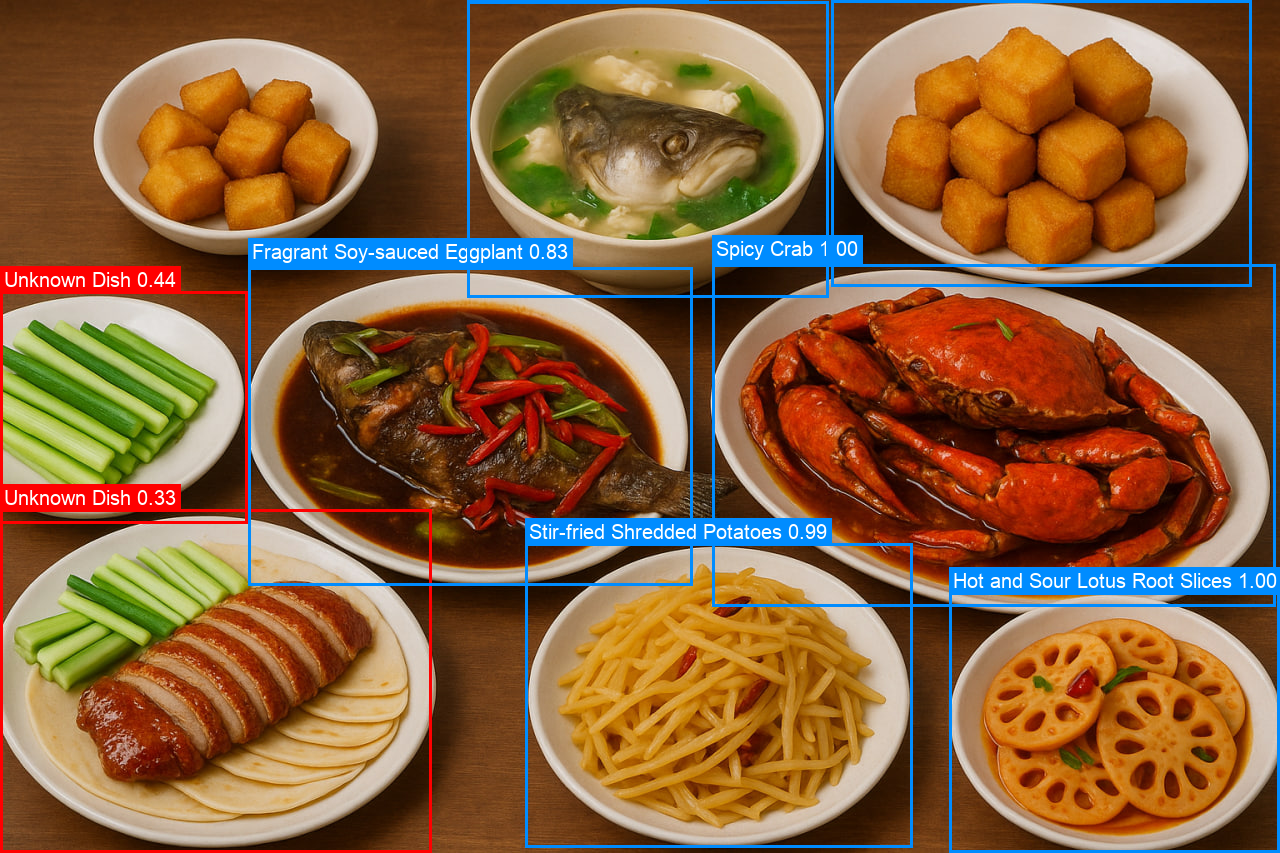

8 detections
{'box_xyxy': (712, 264, 1275, 606), 'cls_id': 13, 'cls_name': 'Spicy Crab', 'score': 0.9981687068939209}
{'box_xyxy': (0, 509, 431, 852), 'cls_id': -1, 'cls_name': 'Unknown Dish', 'score': 0.3294799029827118}
{'box_xyxy': (248, 267, 692, 585), 'cls_id': 6, 'cls_name': 'Fragrant Soy-sauced Eggplant', 'score': 0.8270706534385681}
{'box_xyxy': (831, 0, 1251, 286), 'cls_id': 7, 'cls_name': 'Fried Milk Custard', 'score': 0.9734140634536743}
{'box_xyxy': (525, 543, 912, 847), 'cls_id': 17, 'cls_name': 'Stir-fried Shredded Potatoes', 'score': 0.9912844896316528}
{'box_xyxy': (467, 1, 828, 297), 'cls_id': 5, 'cls_name': 'Fish Head Tofu Soup', 'score': 0.9721678495407104}
{'box_xyxy': (949, 592, 1279, 852), 'cls_id': 9, 'cls_name': 'Hot and Sour Lotus Root Slices', 'score': 0.9999856948852539}
{'box_xyxy': (0, 291, 247, 523), 'cls_id': -1, 'cls_name': 'Unknown Dish', 'score': 0.4380434453487396}


In [14]:
# Predict single image
TEST_IMAGE = "data_clean/prediction/detection/Test3.jpg"
dets, vis = detect_and_classify(TEST_IMAGE, min_box_area=3000, clf_pad=0.10, box_pad=0.02)
display(vis)
print(f"{len(dets)} detections")
for d in dets:
    print(d)
